# Week 04 Day 5 — Capstone Analysis

## Online Retail Business Analysis

### Business Question
How can an online retail business identify its most valuable products, customers, and markets to improve sales performance?

### Analysis Workflow
1. Data Cleaning
2. Exploratory Data Analysis (EDA)
3. Data Visualisation
4. Statistical Analysis
5. Business Insights and Recommendations

### Dataset
Online Retail Business dataset from Kaggle.

The dataset contains transaction-level information including invoice number,
product, quantity, invoice date, unit price, customer, and country.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

BASE_DIR = Path.cwd()
DAY5_DIR = BASE_DIR / "Week 04" / "Day 5"

df = pd.read_csv(
    DAY5_DIR / "OnlineRetail.csv",
    encoding="latin1"
)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [3]:
# Check missing values and duplicates

print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nCancelled invoices:",
      df["InvoiceNo"].astype(str).str.startswith("C").sum())

print("Negative quantities:", (df["Quantity"] < 0).sum())

print("Zero/negative prices:", (df["UnitPrice"] <= 0).sum())

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicate rows: 5268

Cancelled invoices: 9288
Negative quantities: 10624
Zero/negative prices: 2517


In [4]:
# Data cleaning

clean_df = df.copy()

# Remove duplicate rows
clean_df = clean_df.drop_duplicates()

# Convert InvoiceDate to datetime
clean_df["InvoiceDate"] = pd.to_datetime(
    clean_df["InvoiceDate"],
    errors="coerce"
)

# Remove cancelled invoices
clean_df = clean_df[
    ~clean_df["InvoiceNo"].astype(str).str.startswith("C")
]

# Keep only valid quantities and prices
clean_df = clean_df[clean_df["Quantity"] > 0]
clean_df = clean_df[clean_df["UnitPrice"] > 0]

# Fill missing product descriptions
clean_df["Description"] = clean_df["Description"].fillna("Unknown Product")

# Keep CustomerID missing values for transaction-level analysis
clean_df["CustomerID"] = clean_df["CustomerID"].astype("Int64")

# Create Revenue
clean_df["Revenue"] = (
    clean_df["Quantity"] * clean_df["UnitPrice"]
)

# Create Month
clean_df["Month"] = clean_df["InvoiceDate"].dt.to_period("M").astype(str)

print("Original rows:", len(df))
print("Cleaned rows:", len(clean_df))
print("Rows removed:", len(df) - len(clean_df))

clean_df.head()

Original rows: 541909
Cleaned rows: 524878
Rows removed: 17031


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-01-12 08:26:00,2.55,17850,United Kingdom,15.30,2010-01
1,536365,71053,WHITE METAL LANTERN,6,2010-01-12 08:26:00,3.39,17850,United Kingdom,20.34,2010-01
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-01-12 08:26:00,2.75,17850,United Kingdom,22.00,2010-01
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-01-12 08:26:00,3.39,17850,United Kingdom,20.34,2010-01
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-01-12 08:26:00,3.39,17850,United Kingdom,20.34,2010-01


In [5]:
# Overall business metrics

total_revenue = clean_df["Revenue"].sum()
total_invoices = clean_df["InvoiceNo"].nunique()
total_products = clean_df["StockCode"].nunique()
total_countries = clean_df["Country"].nunique()
total_customers = clean_df["CustomerID"].nunique()

print("Total Revenue:", round(total_revenue, 2))
print("Total Invoices:", total_invoices)
print("Total Products:", total_products)
print("Total Countries:", total_countries)
print("Total Customers:", total_customers)

Total Revenue: 10642110.8
Total Invoices: 19960
Total Products: 3922
Total Countries: 38
Total Customers: 4338


In [6]:
# Top 10 products by revenue

top_products = (
    clean_df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Products by Revenue:")
display(top_products.to_frame(name="Revenue"))

Top 10 Products by Revenue:


,Revenue
Description,
DOTCOM POSTAGE,206248.77
REGENCY CAKESTAND 3 TIER,174156.54
"PAPER CRAFT , LITTLE BIRDIE",168469.60
WHITE HANGING HEART T-LIGHT HOLDER,106236.72
PARTY BUNTING,99445.23
JUMBO BAG RED RETROSPOT,94159.81
MEDIUM CERAMIC TOP STORAGE JAR,81700.92
POSTAGE,78101.88
Manual,77752.82


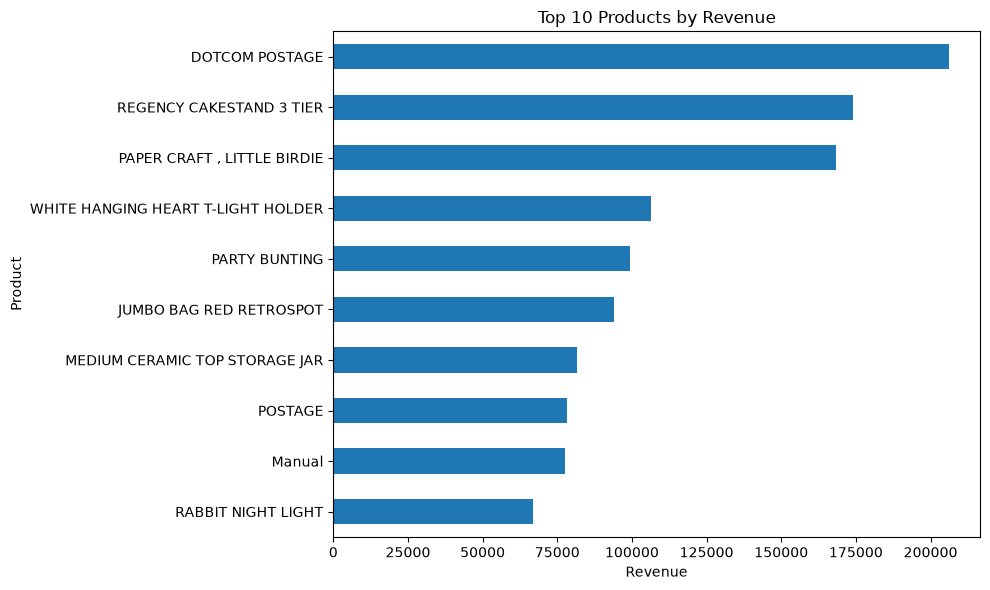

In [7]:
# Visualisation 1: Top 10 products by revenue

plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()

plt.show()

In [8]:
# Revenue by country

country_revenue = (
    clean_df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Countries by Revenue:")
display(country_revenue.to_frame(name="Revenue"))

Top 10 Countries by Revenue:


,Revenue
Country,
United Kingdom,9001744.094
Netherlands,285446.340
EIRE,283140.520
Germany,228678.400
France,209625.370
Australia,138453.810
Spain,61558.560
Switzerland,57067.600
Belgium,41196.340


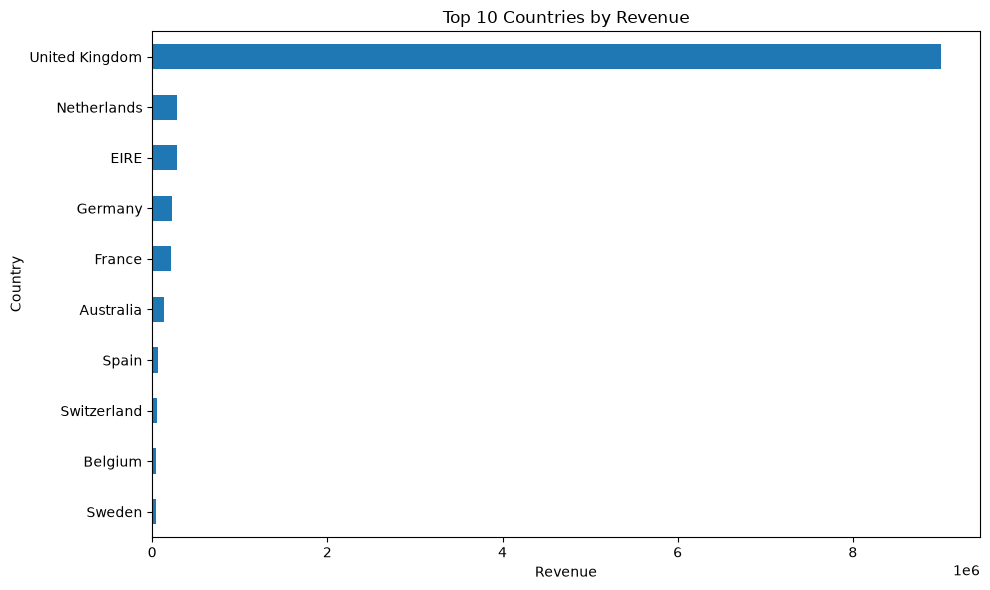

In [9]:
# Visualisation 2: Top 10 countries by revenue

plt.figure(figsize=(10, 6))

country_revenue.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.tight_layout()

plt.show()


In [10]:
# Monthly revenue trend

monthly_revenue = (
    clean_df.groupby("Month")["Revenue"]
    .sum()
)

print("Monthly Revenue:")
display(monthly_revenue.to_frame(name="Revenue"))

Monthly Revenue:


,Revenue
Month,
2010-01,58776.79
2010-02,47629.42
2010-03,46898.63
2010-05,31364.63
2010-06,54624.15
2010-07,99553.85
2010-08,45235.36
2010-09,53548.19
2010-10,59021.02


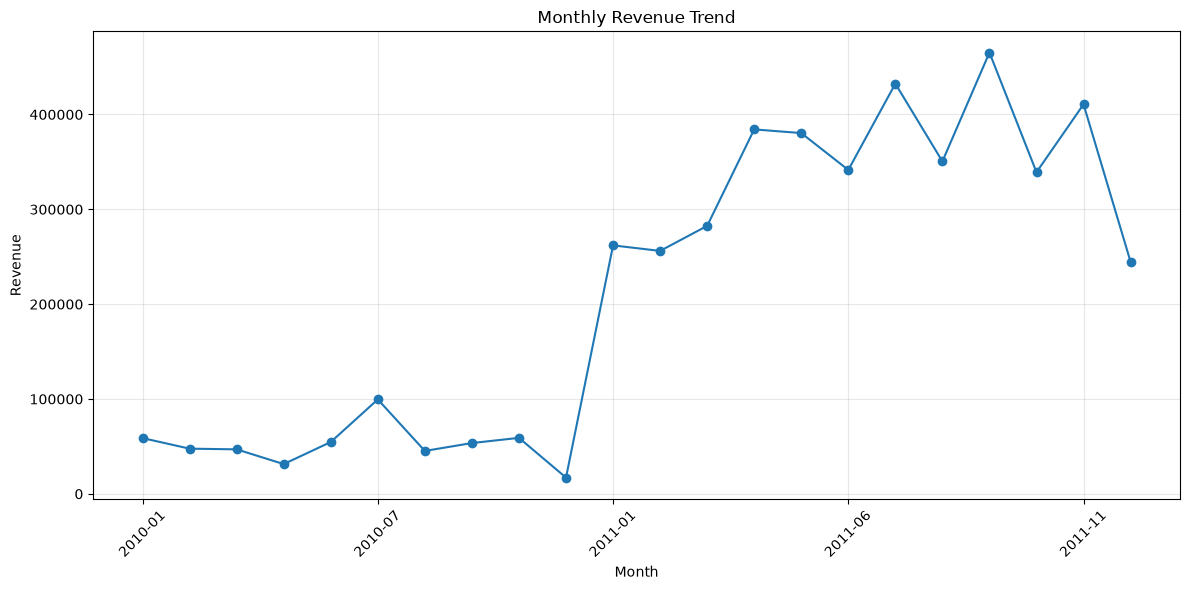

In [11]:
# Visualisation 3: Monthly revenue trend

plt.figure(figsize=(12, 6))

monthly_revenue.plot(kind="line", marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [12]:
# Statistical analysis
# Compare average transaction revenue between the UK and Netherlands

uk_revenue = clean_df[
    clean_df["Country"] == "United Kingdom"
]["Revenue"]

netherlands_revenue = clean_df[
    clean_df["Country"] == "Netherlands"
]["Revenue"]

t_stat, p_value = stats.ttest_ind(
    uk_revenue,
    netherlands_revenue,
    equal_var=False
)

print("United Kingdom transactions:", len(uk_revenue))
print("Netherlands transactions:", len(netherlands_revenue))

print("\nUK average revenue:",
      round(uk_revenue.mean(), 2))

print("Netherlands average revenue:",
      round(netherlands_revenue.mean(), 2))

print("\nT-statistic:", round(t_stat, 4))
print("P-value:", round(p_value, 6))

if p_value < 0.05:
    print("Conclusion: The difference in average transaction revenue is statistically significant.")
else:
    print("Conclusion: The difference in average transaction revenue is not statistically significant.")

United Kingdom transactions: 479985
Netherlands transactions: 2359

UK average revenue: 18.75
Netherlands average revenue: 121.0

T-statistic: -30.053
P-value: 0.0
Conclusion: The difference in average transaction revenue is statistically significant.
